In [18]:
import pandas as pd
import numpy as np
import random
import json
import joblib
import matplotlib.pyplot as plt
%matplotlib widget

from fastembed import TextEmbedding
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, make_scorer, precision_score
)

# Reproducibility
random.seed(42)
np.random.seed(42)

In [12]:
# ── CELL 1: Load ──────────────────────────────────────────
df = pd.read_csv("intent_classifier.csv")
queries = df['query'].tolist()
labels = df['result'].tolist()
print(f"Loaded {len(queries)} examples.")

Loaded 2189 examples.


In [14]:
# ── CELL 2: Split first, then embed ───────────────────────
# Three-way split: 80% train, 10% val, 10% test
queries_temp, queries_test, y_temp, y_test = train_test_split(
    queries, labels, test_size=0.1, random_state=42, stratify=labels
)
queries_train, queries_val, y_train, y_val = train_test_split(
    queries_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

print(f"Train: {len(queries_train)} | Val: {len(queries_val)} | Test: {len(queries_test)}")

embedding_model = TextEmbedding("BAAI/bge-small-en-v1.5")

X_train = np.array(list(embedding_model.embed(queries_train)))
X_val   = np.array(list(embedding_model.embed(queries_val)))
X_test  = np.array(list(embedding_model.embed(queries_test)))

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

Train: 1751 | Val: 219 | Test: 219


In [16]:
# ── CELL 3: Grid search on train, score on precision ──────
cacheable_precision = make_scorer(precision_score, pos_label=1)

base_clf = MLPClassifier(
    max_iter=10000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (128,), (256,), (64, 32), (128, 64), (256, 128), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'solver': ['adam', 'lbfgs'],
    'learning_rate_init': [0.001, 0.0001]
}

grid_search = GridSearchCV(
    base_clf, param_grid, cv=5,
    scoring=cacheable_precision,
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV precision: {grid_search.best_score_:.4f}")

classifier = grid_search.best_estimator_

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Best params: {'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001, 'solver': 'lbfgs'}
Best CV precision: 0.9329


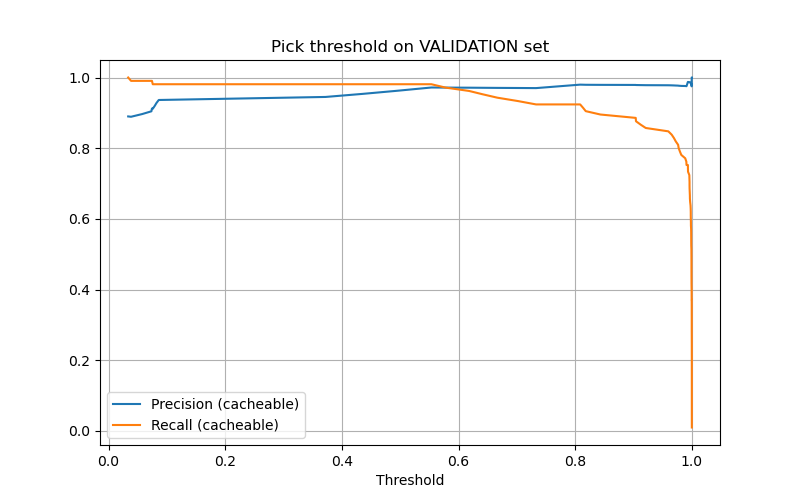

In [58]:
# ── CELL 4: Validate threshold on val set ─────────────────
y_val_proba = classifier.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label='Precision (cacheable)')
plt.plot(thresholds, recall[:-1], label='Recall (cacheable)')
plt.xlabel('Threshold')
plt.title('Pick threshold on VALIDATION set')
plt.legend()
plt.grid(True)
plt.show()

# Set threshold here based on the curve — targeting precision >= 0.95
THRESHOLD = 0.97  # adjust after inspecting the plot

In [59]:
# ── CELL 5: Final evaluation on test set (once only) ──────
y_test_proba = classifier.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(f"\nFalse cache rate (bypass → cached): {cm[0][1]} / {cm[0].sum()}")
print(f"False bypass rate (cache → bypassed): {cm[1][0]} / {cm[1].sum()}")

roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"ROC AUC: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       0.83      1.00      0.91       114
           1       1.00      0.78      0.88       105

    accuracy                           0.89       219
   macro avg       0.92      0.89      0.89       219
weighted avg       0.91      0.89      0.89       219


False cache rate (bypass → cached): 0 / 114
False bypass rate (cache → bypassed): 23 / 105
ROC AUC: 0.9890


In [60]:
# 2. Find the exact row positions of the False Positives 
# (Where the true answer was 0, but the model boldly predicted 1)
mistake_positions = np.where((y_test == 0) & (y_test_pred == 1))[0]

print(f"--- FOUND {len(mistake_positions)} FALSE POSITIVES ---")

# 3. Loop through those positions and print the data
for pos in mistake_positions:
    # Get the model's exact confidence score for this mistake
    confidence = y_test_proba[pos]
    
    # IMPORTANT: Replace 'df_test["query"]' with whatever variable 
    # holds your original, raw English text for the test set!
    # If your original text was a list called 'test_texts', use test_texts[pos]
    query_text = queries_test[pos] 
    
    print(f"Model Confidence: {confidence:.4f} | Text: {query_text}")

--- FOUND 0 FALSE POSITIVES ---


In [61]:
# ── CELL 6: Save model + metadata ─────────────────────────
joblib.dump(classifier, "intent_mlp_model.joblib")

metadata = {
    "threshold": THRESHOLD,
    "embedding_model": "BAAI/bge-small-en-v1.5",
    "embedding_dim": 384,
    "classes": {"0": "bypass", "1": "cacheable"},
    "best_params": grid_search.best_params_,
    "test_roc_auc": float(roc_auc),
    "training_size": int(len(X_train))
}

with open("intent_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Done. Model and metadata saved.")

Done. Model and metadata saved.
